# 暂退法（Dropout）

## 环境配置


In [1]:
import logging
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("torch_npu").setLevel(logging.WARNING)
import os
import sys
sys.path.insert(0, "..")
os.environ["TILE_FWK_DEVICE_ID"] = "0"
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    import pypto
    import torch
    from torch import nn
    import torch_npu

warnings.filterwarnings("ignore", message="Permission mismatch")
warnings.filterwarnings("ignore", message="TASK_QUEUE_ENABLE")
warnings.filterwarnings("ignore", message="Cannot create tensor")
import matplotlib.pyplot as plt

device_id = int(os.environ["TILE_FWK_DEVICE_ID"])
torch.npu.set_device(device_id)
device = f"npu:{device_id}"
pypto.pypto_impl.DeviceInit()

from src.utils import load_data_fashion_mnist, train_epoch_ch3, train_ch3, evaluate_accuracy, Animator, set_axes, plot, use_svg_display
import numpy as np
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats("png")


class NpuIter:
    """可重复迭代的设备数据迭代器：train_ch3 等每轮 epoch 会多次迭代同一迭代器。"""
    def __init__(self, dl):
        self.dl = dl

    def __iter__(self):
        for X, y in self.dl:
            yield X.to(device), y.to(device)


def npu_iter(dl):
    return NpuIter(dl)

from IPython import display


## 练习4.6.1

如果更改第一层和第二层的暂退概率，会发生什么情况？具体地说，如果交换这两个层，会发生什么情况？设计一个实验来回答这些问题，定量描述该结果，并总结定性的结论。

**解答：** 交换两层的暂退概率会导致结果变差。提高暂退概率也会使得loss更大、训练预测的准确度下降，同时调整第一层暂退概率带来的影响比第二层的大。

以下使用 `torch` 编程进行验证：


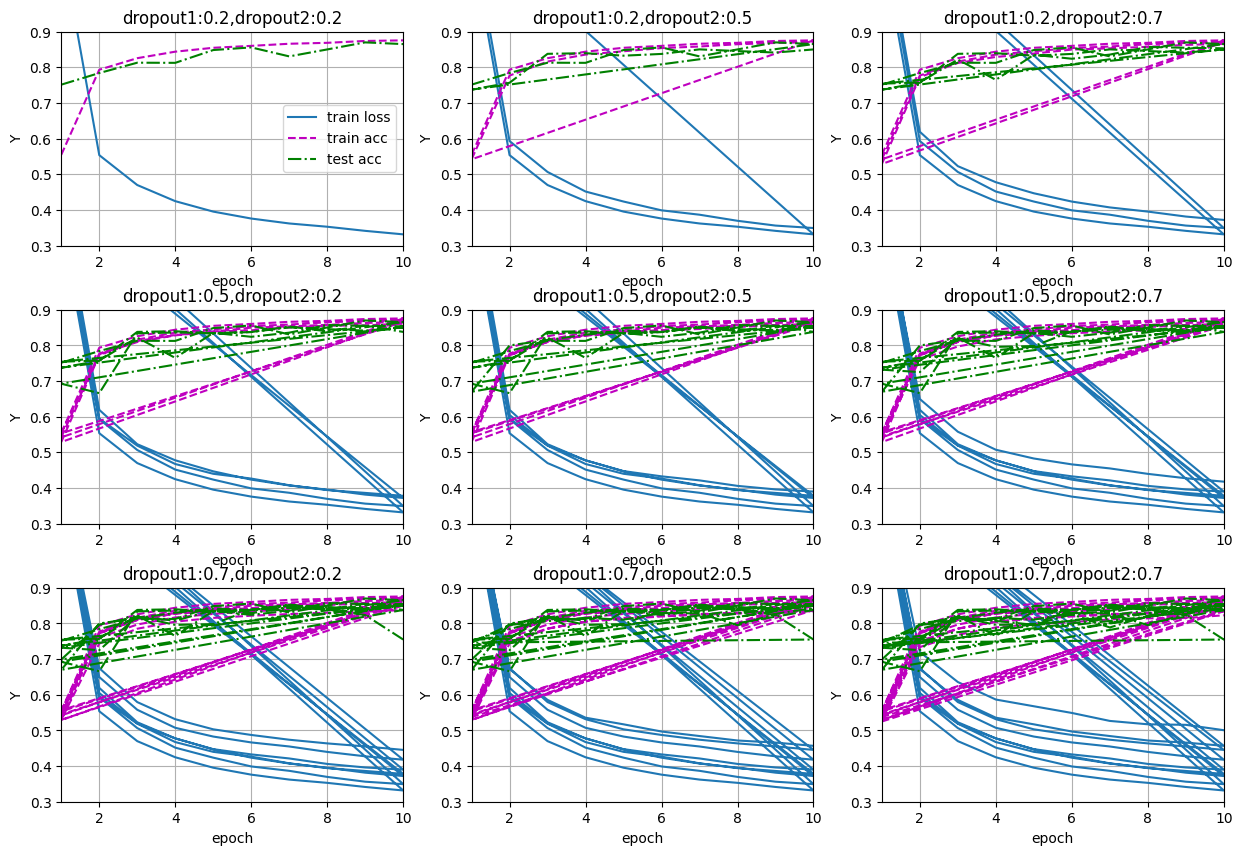

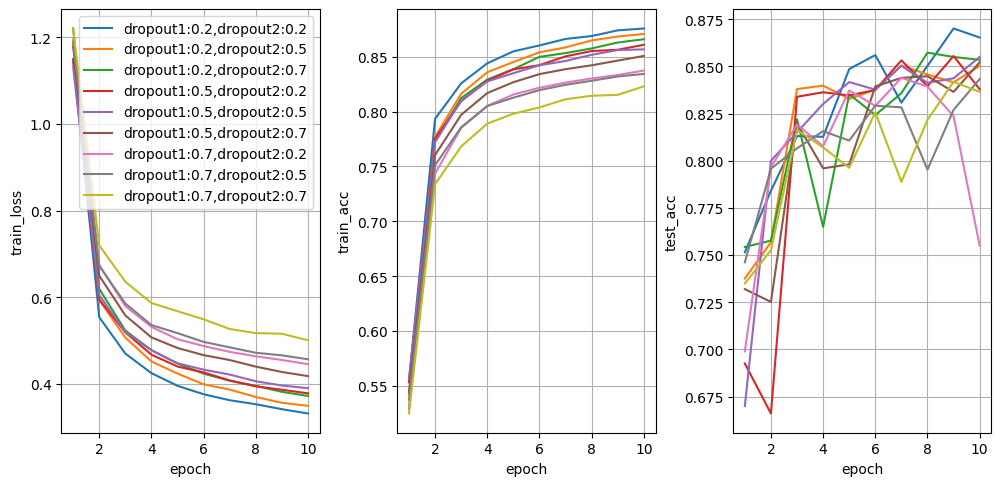

In [2]:
import numpy as np

class myAnimator:
    """在动画中绘制数据"""
    def __init__(self, xlabel=None, ylabel=None, legend=None, xlim=None,
                 ylim=None, xscale='linear', yscale='linear',
                 fmts=('-', 'm--', 'g-.', 'r:'), nrows=1, ncols=1,
                 figsize=(4.5, 3.5), wspace=0.5, hspace=0.8):
        if legend is None:
            legend = []
        # 统一使用 PNG 输出（本系列不使用 SVG）
        self.fig, self.axes = plt.subplots(nrows, ncols, figsize=figsize)
        if nrows * ncols == 1:
            self.axes = [self.axes, ]
        self.config_axes = lambda axesnx, axesny: set_axes(
            self.axes[axesnx, axesny], xlabel, ylabel, xlim, ylim, xscale, yscale, legend
        ) if axesnx == 0 and axesny == 0 else set_axes(
            self.axes[axesnx, axesny], xlabel, ylabel, xlim, ylim, xscale, yscale, [])
        plt.subplots_adjust(wspace=wspace, hspace=hspace)
        self.X, self.Y, self.fmts = None, None, fmts

    def add(self, axesnx, axesny, x, y, title=None):
        if not hasattr(y, "__len__"):
            y = [y]
        n = len(y)
        if not hasattr(x, "__len__"):
            x = [x] * n
        if not self.X:
            self.X = [[] for _ in range(n)]
        if not self.Y:
            self.Y = [[] for _ in range(n)]
        for i, (a, b) in enumerate(zip(x, y)):
            if a is not None and b is not None:
                self.X[i].append(a)
                self.Y[i].append(b)
        self.axes[axesnx, axesny].cla()
        if title:
            self.axes[axesnx, axesny].set_title(title)
        for x, y, fmt in zip(self.X, self.Y, self.fmts):
            self.axes[axesnx, axesny].plot(x, y, fmt)
        self.config_axes(axesnx, axesny)
        display.display(self.fig)
        display.clear_output(wait=True)

def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)

def Net(dropout1=0.5, dropout2=0.2, num_inputs=784, num_outputs=10, 
        num_hiddens1=256, num_hiddens2=256):
    net = nn.Sequential(nn.Flatten(),
                        nn.Linear(num_inputs, num_hiddens1),
                        nn.ReLU(),
                        nn.Dropout(dropout1),
                        nn.Linear(num_hiddens1, num_hiddens2),
                        nn.ReLU(),
                        nn.Dropout(dropout2),
                        nn.Linear(num_hiddens2, num_outputs))
    return net

def changedropout(dropout1list=[0.5], dropout2list=[0.2], num_epochs=10, lr=0.5,
                  batch_size=256, num_inputs=784, num_outputs=10, 
                  num_hiddens1=256, num_hiddens2=256, wd=None, figsize=(15, 10),
                  wspace=0.2, hspace=0.3, xlim=[1, 10], ylim=[0.3, 0.9], show=True):
    ndropout1, ndropout2 = len(dropout1list), len(dropout2list)
    train_iter, test_iter = load_data_fashion_mnist(batch_size)
    if show:
        if (ndropout1 == 1) and (ndropout2 == 1):
            animator = Animator(xlabel='epoch', ylabel='Y', xlim=xlim, ylim=ylim,
                                legend=['train loss', 'train acc', 'test acc'], figsize=figsize)
        else:
            animator = myAnimator(xlabel='epoch', ylabel='Y', xlim=[1, num_epochs], ylim=ylim,
                                  legend=['train loss', 'train acc', 'test acc'],
                                  nrows=ndropout1, ncols=ndropout2, figsize=figsize,
                                  wspace=wspace, hspace=hspace)
    train_losslist = np.zeros((ndropout1, ndropout2, num_epochs))
    train_acclist = np.zeros((ndropout1, ndropout2, num_epochs))
    test_acclist = np.zeros((ndropout1, ndropout2, num_epochs))
    for i in range(ndropout1):
        for j in range(ndropout2):
            dropout1, dropout2 = dropout1list[i], dropout2list[j]
            net = Net(dropout1, dropout2)
            net.apply(init_weights)
            net = net.to(device)
            loss = nn.CrossEntropyLoss(reduction='none')
            if wd is None:
                trainer = torch.optim.SGD(net.parameters(), lr=lr)
            else:
                paramslist = []
                for m in net:
                    if type(m) == nn.Linear:
                        paramslist.append({"params": m.weight, 'weight_decay': wd})
                        paramslist.append({"params": m.bias})
                trainer = torch.optim.SGD(paramslist, lr=lr)
            for epoch in range(num_epochs):
                train_metrics = train_epoch_ch3(net, npu_iter(train_iter), loss, trainer)
                test_acc = evaluate_accuracy(net, npu_iter(test_iter))
                train_losslist[i, j, epoch] = train_metrics[0]
                train_acclist[i, j, epoch] = train_metrics[1]
                test_acclist[i, j, epoch] = test_acc
                if show:
                    if ndropout1 == 1 and ndropout2 == 1:
                        animator.add(epoch + 1, train_metrics + (test_acc,))
                    else:
                        animator.add(i, j, epoch + 1, train_metrics + (test_acc,),
                                     title=f"dropout1:{dropout1},dropout2:{dropout2}")
    if show:
        animator.X, animator.Y = None, None
    train_loss, train_acc = train_metrics
    return train_losslist, train_acclist, test_acclist

dropout1list, dropout2list = [0.2, 0.5, 0.7], [0.2, 0.5, 0.7]
train_losslist, train_acclist, test_acclist = changedropout(
    dropout1list=[0.2, 0.5, 0.7], dropout2list=[0.2, 0.5, 0.7])

plt.figure(figsize=(12, 5.5))
plt.subplot(131)
plot(list(range(1, 11)), np.vstack([train_losslist[i, :, :] for i in range(3)]).T,
     'epoch', 'train_loss',
     legend=[f'dropout1:{d1},dropout2:{d2}' for d1 in dropout1list for d2 in dropout2list],
     axes=plt.gca())
plt.subplot(132)
plot(list(range(1, 11)), np.vstack([train_acclist[i, :, :] for i in range(3)]).T,
     'epoch', 'train_acc',
     axes=plt.gca())
plt.subplot(133)
plot(list(range(1, 11)), np.vstack([test_acclist[i, :, :] for i in range(3)]).T,
     'epoch', 'test_acc',
     axes=plt.gca())
plt.subplots_adjust(wspace=0.3, hspace=0)


使用 `PyPTO` 编程进行验证:


In [3]:
from src.utils import load_data_fashion_mnist, Animator
from src.pypto_ops import PyPTOLinear, PyPTOReLU, PyPTODropout, PyPTOSoftmaxCrossEntropyLossFunction

train_iter_main, test_iter_main = load_data_fashion_mnist(256, resize=None)

def loss_ce_none(y_hat, y):
    return PyPTOSoftmaxCrossEntropyLossFunction.apply(y_hat, y, 10)

def train_epoch_npu(net, train_iter, updater):
    net.train()
    loss_sum = torch.zeros((), device=device)
    acc_sum = torch.zeros((), device=device)
    n = 0
    for X, y in train_iter:
        X, y = X.to(device), y.to(device)
        y_hat = net(X)
        l = loss_ce_none(y_hat, y)
        updater.zero_grad()
        l.mean().backward()
        updater.step()
        loss_sum += l.detach().sum()
        acc_sum += (y_hat.detach().argmax(dim=1) == y).sum()
        n += y.numel()
    return loss_sum.item() / n, acc_sum.item() / n

def evaluate_accuracy_npu(net, data_iter):
    net.eval()
    acc_sum = torch.zeros((), device=device)
    n = 0
    with torch.no_grad():
        for X, y in data_iter:
            X, y = X.to(device), y.to(device)
            acc_sum += (net(X).argmax(dim=1) == y).sum()
            n += y.numel()
    return acc_sum.item() / n

def Net_npu(dropout1=0.5, dropout2=0.2, num_hiddens1=256, num_hiddens2=256):
    return nn.Sequential(
        nn.Flatten(),
        PyPTOLinear(784, num_hiddens1),
        PyPTOReLU(),
        PyPTODropout(dropout1),
        PyPTOLinear(num_hiddens1, num_hiddens2),
        PyPTOReLU(),
        PyPTODropout(dropout2),
        PyPTOLinear(num_hiddens2, 10),
    ).to(device)

def changedropout_npu(dropout1list=[0.5], dropout2list=[0.2], num_epochs=10,
                      lr=0.5, batch_size=256, num_hiddens1=256, num_hiddens2=256,
                      ylim=None, show=True):
    nd1, nd2 = len(dropout1list), len(dropout2list)
    train_iter, test_iter = load_data_fashion_mnist(batch_size)
    train_losses = np.zeros((nd1, nd2, num_epochs))
    train_accs = np.zeros((nd1, nd2, num_epochs))
    test_accs = np.zeros((nd1, nd2, num_epochs))
    for i in range(nd1):
        for j in range(nd2):
            d1, d2 = dropout1list[i], dropout2list[j]
            net = Net_npu(d1, d2, num_hiddens1, num_hiddens2)
            updater = torch.optim.SGD(net.parameters(), lr=lr)
            if show:
                animator = Animator(xlabel='epoch', ylabel='Y',
                                    xlim=[1, num_epochs], ylim=ylim or [0.3, 0.9],
                                    legend=['train loss', 'train acc', 'test acc'])
            for epoch in range(num_epochs):
                tr_metrics = train_epoch_npu(net, train_iter, updater)
                te_acc = evaluate_accuracy_npu(net, test_iter)
                train_losses[i,j,epoch] = tr_metrics[0]
                train_accs[i,j,epoch] = tr_metrics[1]
                test_accs[i,j,epoch] = te_acc
                if show:
                    animator.add(epoch + 1, tr_metrics + (te_acc,))
            if show: animator.X = animator.Y = None
            print(f'dropout1={d1},dropout2={d2}: train_loss={tr_metrics[0]:.4f} train_acc={tr_metrics[1]:.4f} test_acc={te_acc:.4f}', flush=True)
    return train_losses, train_accs, test_accs


dropout1=0.7,dropout2=0.7: train_loss=0.4965 train_acc=0.8223 test_acc=0.8273


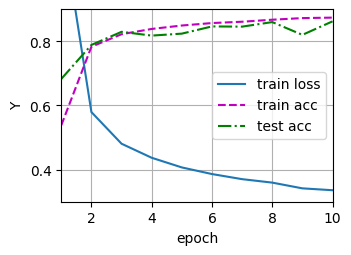

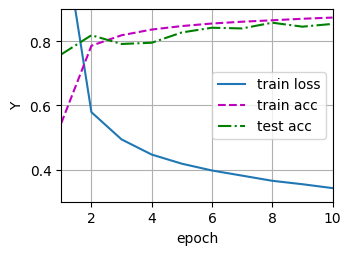

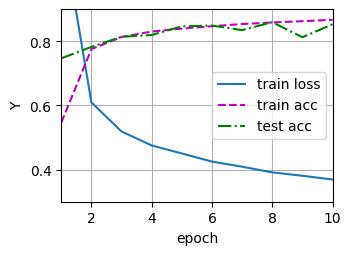

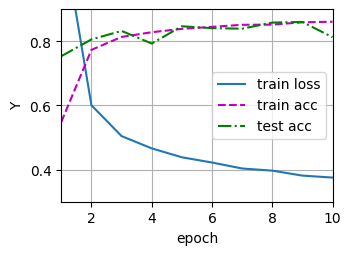

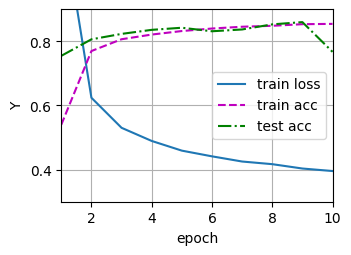

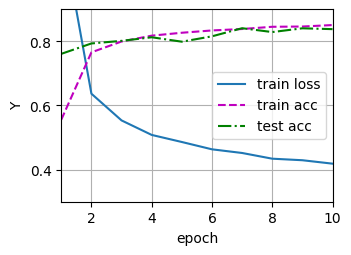

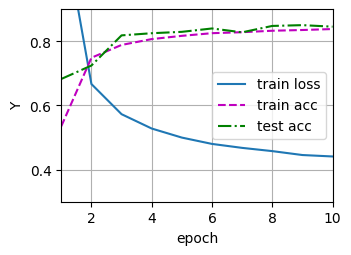

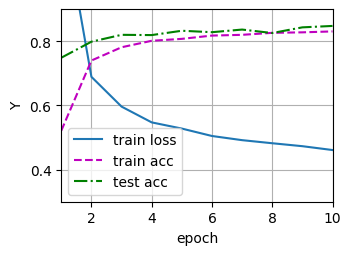

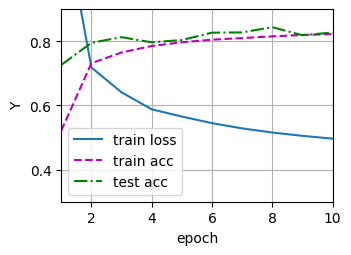

In [4]:
# 3x3 dropout grid (NPU + pypto)
train_losslist, train_acclist, test_acclist = changedropout_npu(
    dropout1list=[0.2, 0.5, 0.7], dropout2list=[0.2, 0.5, 0.7])


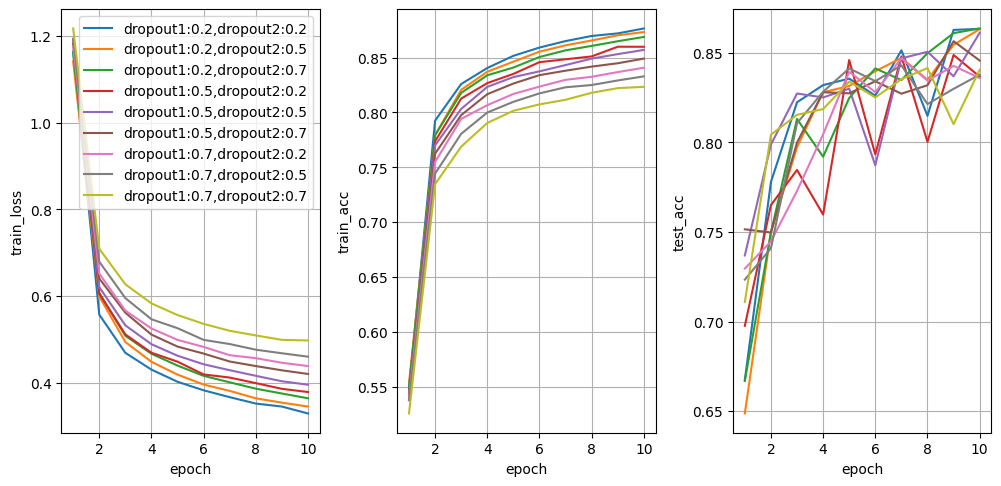

In [5]:
import matplotlib.pyplot as plt
from src.utils import plot
# 绘制 dropout 网格对比
dropout1list, dropout2list = [0.2, 0.5, 0.7], [0.2, 0.5, 0.7]
plt.figure(figsize=(12, 5.5))
plt.subplot(131)
# np.vstack produces (9,10): 9 curves × 10 epochs. Transpose to (9,10) for dual dimension plot.
plot(list(range(1, 11)),
         np.vstack([train_losslist[i,:,:] for i in range(3)]).T,
         'epoch', 'train_loss',
         legend=[f'dropout1:{d1},dropout2:{d2}'
                 for d1 in dropout1list for d2 in dropout2list],
         axes=plt.gca())
plt.subplot(132)
plot(list(range(1, 11)),
         np.vstack([train_acclist[i,:,:] for i in range(3)]).T,
         'epoch', 'train_acc',
         axes=plt.gca())
plt.subplot(133)
plot(list(range(1, 11)),
         np.vstack([test_acclist[i,:,:] for i in range(3)]).T,
         'epoch', 'test_acc',
         axes=plt.gca())
plt.subplots_adjust(wspace=0.3, hspace=0)


## 练习4.6.2

增加训练轮数，并将使用暂退法和不使用暂退法时获得的结果进行比较。

**解答：** 没使用dropout会出现loss值突然上升的情况（这可能是因为学习率设置过高），使用dropout的结果这种情况则会消失。

以下使用 `torch` 编程进行验证：


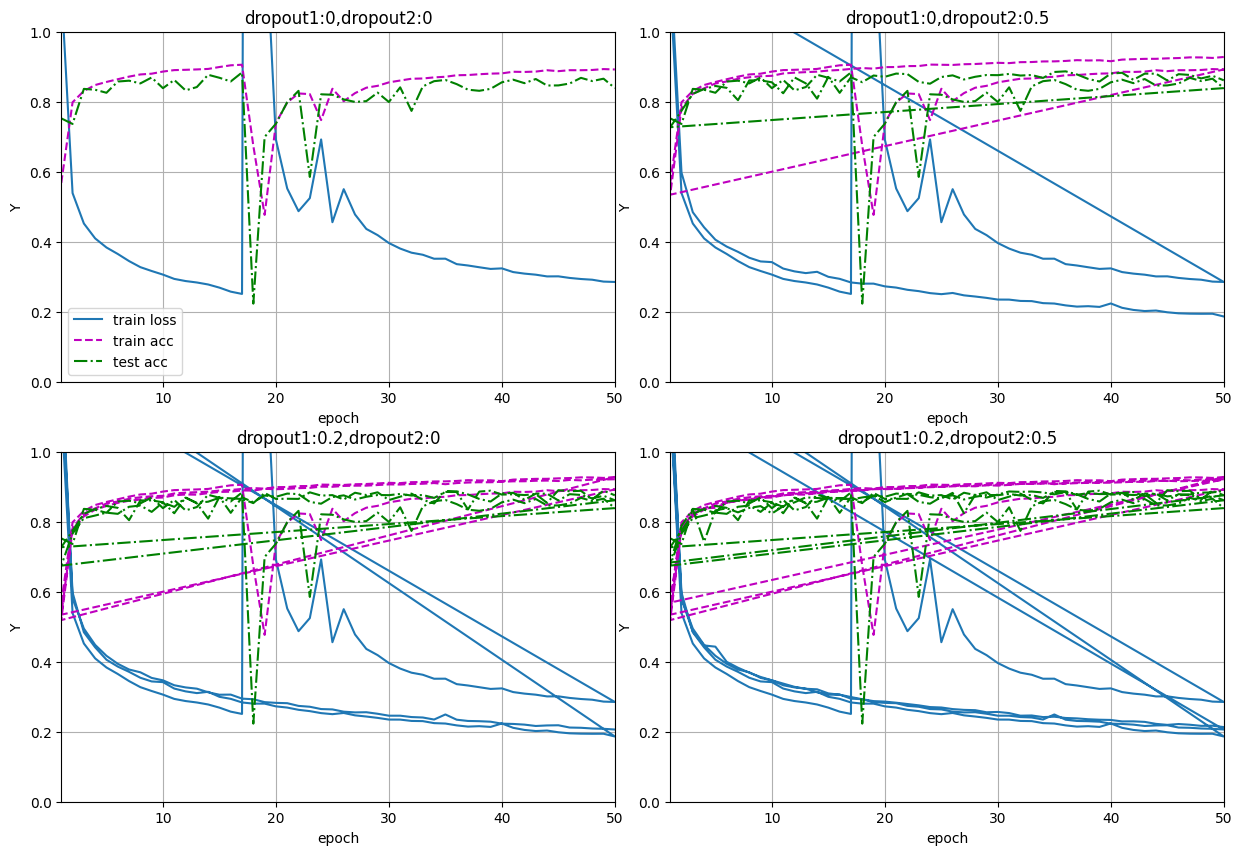

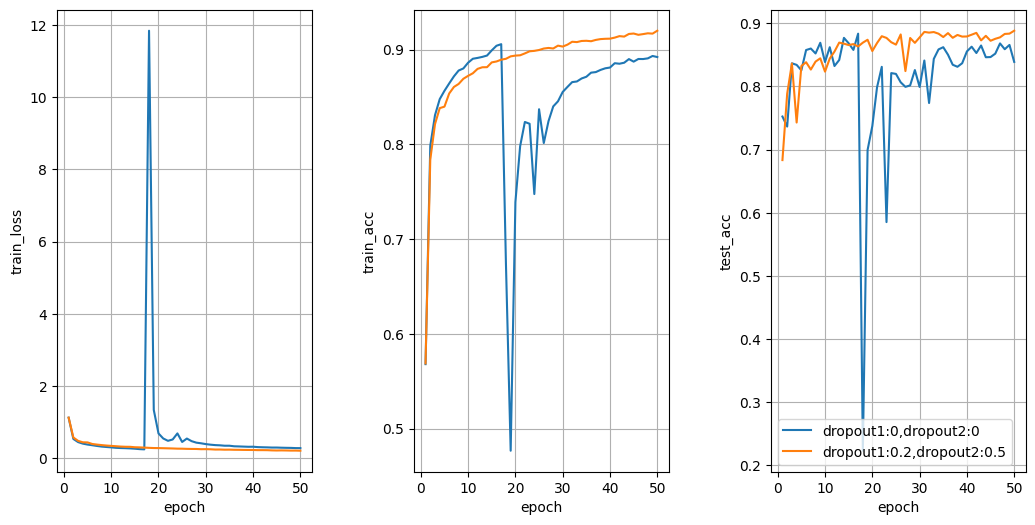

In [6]:
num_epochs = 50
dropout1list, dropout2list = [0, 0.2], [0, 0.5]
train_losslist, train_acclist, test_acclist = changedropout(
    dropout1list=dropout1list, dropout2list=dropout2list,
    num_epochs=num_epochs, wspace=0.1, hspace=0.2, ylim=[0, 1])

plt.figure(figsize=(12.5, 6))
plt.subplot(131)
plot(list(range(1, num_epochs + 1)), np.vstack((train_losslist[0, 0, :], train_losslist[1, 1, :])).T,
     'epoch', 'train_loss',
     axes=plt.gca())
plt.subplot(132)
plot(list(range(1, num_epochs + 1)), np.vstack((train_acclist[0, 0, :], train_acclist[1, 1, :])).T,
     'epoch', 'train_acc',
     axes=plt.gca())
plt.subplot(133)
plot(list(range(1, num_epochs + 1)), np.vstack((test_acclist[0, 0, :], test_acclist[1, 1, :])).T,
     'epoch', 'test_acc',
     legend=['dropout1:0,dropout2:0', 'dropout1:0.2,dropout2:0.5'],
     axes=plt.gca())
plt.subplots_adjust(wspace=0.4, hspace=0)


使用 `PyPTO` 编程进行验证:


dropout1=0.2,dropout2=0.5: train_loss=0.2530 train_acc=0.9052 test_acc=0.8604



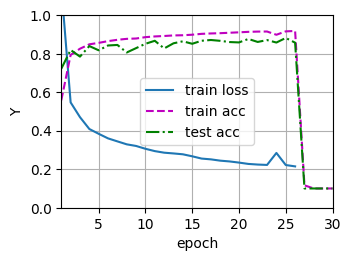

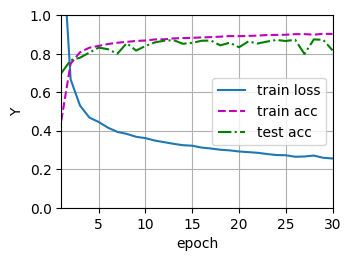

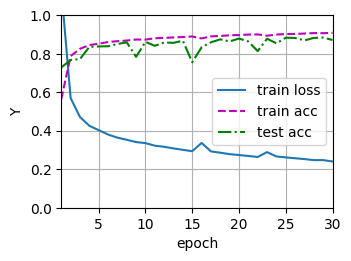

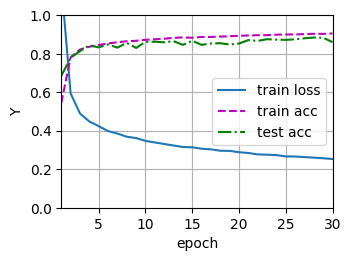

In [7]:
# 练习：暂退率对比（NPU + pypto），epoch 从 50 缩小为 30
num_epochs = 30
dropout1list, dropout2list = [0, 0.2], [0, 0.5]
train_losslist, train_acclist, test_acclist = changedropout_npu(
    dropout1list=dropout1list, dropout2list=dropout2list,
    num_epochs=num_epochs, ylim=[0, 1])


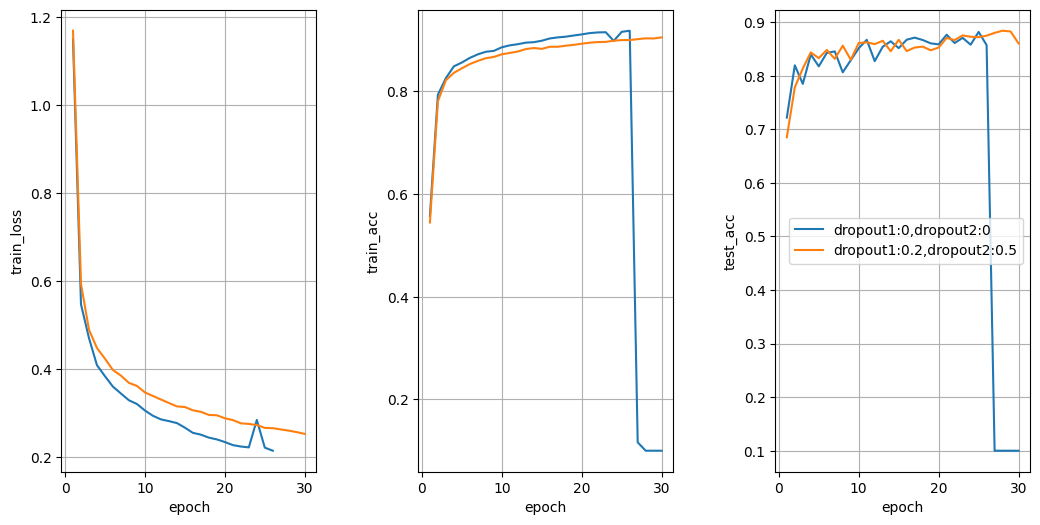

In [8]:
import matplotlib.pyplot as plt
from src.utils import plot
plt.figure(figsize=(12.5, 6))
plt.subplot(131)
plot(list(range(1, num_epochs + 1)),
         np.vstack((train_losslist[0,0,:], train_losslist[1,1,:])).T,
         'epoch', 'train_loss',
         axes=plt.gca())
plt.subplot(132)
plot(list(range(1, num_epochs + 1)),
         np.vstack((train_acclist[0,0,:], train_acclist[1,1,:])).T,
         'epoch', 'train_acc',
         axes=plt.gca())
plt.subplot(133)
plot(list(range(1, num_epochs + 1)),
         np.vstack((test_acclist[0,0,:], test_acclist[1,1,:])).T,
         'epoch', 'test_acc',
         legend=['dropout1:0,dropout2:0', 'dropout1:0.2,dropout2:0.5'],
         axes=plt.gca())
plt.subplots_adjust(wspace=0.4, hspace=0)


## 练习4.6.3

当使用或不使用暂退法时，每个隐藏层中激活值的方差是多少？绘制一个曲线图，以显示这两个模型的每个隐藏层中激活值的方差是如何随时间变化的。

**解答：** 使用暂退法，每个中间活性值$h$以*暂退概率*$p$由随机变量$h'$替换:

$$h' = \begin{cases} 0 & \text{ 概率为 } p \\ \frac{h}{1-p} & \text{ 其他情况} \end{cases}$$

其期望值保持不变，即$E[h'] = h$。方差

$$D(h') = E\left((h'-E(h'))^2\right) = E\left(h'^2\right) - E^2\left(h'\right) = \frac{h^2}{(1-p)} - h^2$$

以下使用 `torch` 编程进行验证：


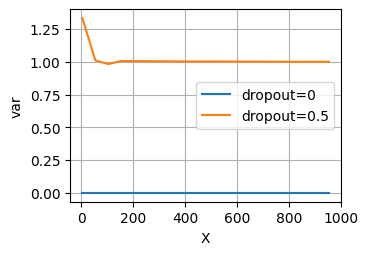

In [2]:
def dropout_layer(X, dropout):
    assert 0 <= dropout <= 1
    if dropout == 1:
        return torch.zeros_like(X)
    if dropout == 0:
        return X
    mask = (torch.rand(X.shape) > dropout).float()
    return mask * X / (1.0 - dropout)

X = torch.arange(16, dtype=torch.float32).reshape((2, 8))
dropout0 = dropout_layer(torch.ones(1, dtype=torch.float32), 0)
dropout0d5 = dropout_layer(torch.ones(1, dtype=torch.float32), 0.5)
var_dropout0d5 = torch.empty(1)
var_dropout0 = torch.empty(1)
for _ in range(1000):
    dropout0d5 = torch.cat([dropout0d5, dropout_layer(torch.ones(1, dtype=torch.float32), 0.5)])
    dropout0 = torch.cat([dropout0, dropout_layer(torch.ones(1, dtype=torch.float32), 0)])
    var_dropout0d5 = torch.cat([var_dropout0d5, torch.var(dropout0d5).reshape(1)])
    var_dropout0 = torch.cat([var_dropout0, torch.var(dropout0).reshape(1)])

plot(torch.arange(2, 1003)[2:-1:50],
     [var_dropout0.detach()[2:-1:50], var_dropout0d5.detach()[2:-1:50]],
     'X', 'var', legend=['dropout=0', 'dropout=0.5'])


使用 `PyPTO` 编程进行验证:


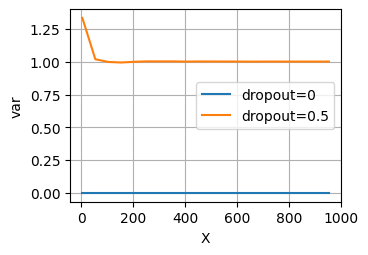

In [3]:
import matplotlib.pyplot as plt
from src.utils import plot
# import见4.6.1
def dropout_layer(X, dropout):
    assert 0 <= dropout <= 1
    if dropout == 1:
        return torch.zeros_like(X)
    if dropout == 0:
        return X
    mask = (torch.rand(X.shape, device=X.device) > dropout).float()
    return mask * X / (1.0 - dropout)

dropout0 = dropout_layer(torch.ones(1, dtype=torch.float32), 0)
dropout0d5 = dropout_layer(torch.ones(1, dtype=torch.float32), 0.5)
var_dropout0d5 = torch.empty(1)
var_dropout0 = torch.empty(1)
for _ in range(1000):
    dropout0d5 = torch.cat([dropout0d5, dropout_layer(
        torch.ones(1, dtype=torch.float32), 0.5)])
    dropout0 = torch.cat([dropout0, dropout_layer(
        torch.ones(1, dtype=torch.float32), 0)])
    var_dropout0d5 = torch.cat([var_dropout0d5,
        torch.var(dropout0d5).reshape(1)])
    var_dropout0 = torch.cat([var_dropout0,
        torch.var(dropout0).reshape(1)])

plot(torch.arange(2, 1003)[2:-1:50],
         [var_dropout0.detach()[2:-1:50], var_dropout0d5.detach()[2:-1:50]],
         'X', 'var', legend=['dropout=0', 'dropout=0.5'])


## 练习4.6.4

为什么在测试时通常不使用暂退法？

**解答：** 训练时使用暂退法是为了防止模型过拟合，提高网络泛化能力，而测试时我们希望可以用上所有的参数，减少参数反而会影响网络稳定性。

## 练习4.6.5

以本节中的模型为例，比较使用暂退法和权重衰减的效果。如果同时使用暂退法和权重衰减，会发生什么情况？结果是累加的吗？

**解答：** 三者测试精度接近（下表为本 notebook torch 版 10 次重复实验的平均值）：单独使用暂退法 0.8533，同时使用暂退法和权重衰减 0.8471，单独使用权重衰减 0.8489。同时使用暂退法和权重衰减的收益**并非累加**：其测试精度略低于单独使用暂退法，且训练损失与单独使用暂退法相当。可见这两种正则化手段组合后没有叠加效果，在实际中应结合验证集效果选择。

<table style="margin-left: 0; margin-right: auto; width: auto; text-align: left;">
  <tr>
    <th style="padding: 8px; text-align: left;">method</th>
    <th style="padding: 8px; text-align: left;">dropout1</th>
    <th style="padding: 8px; text-align: left;">dropout2</th>
    <th style="padding: 8px; text-align: left;">train loss</th>
    <th style="padding: 8px; text-align: left;">train acc</th>
    <th style="padding: 8px; text-align: left;">test acc</th>
  </tr>
  <tr>
    <td style="padding: 8px;">dropout</td>
    <td style="padding: 8px;">0.2</td>
    <td style="padding: 8px;">0.5</td>
    <td style="padding: 8px;">0.3457</td>
    <td style="padding: 8px;">0.8731</td>
    <td style="padding: 8px;">0.8533</td>
  </tr>
  <tr>
    <td style="padding: 8px;">dropout and weight decay</td>
    <td style="padding: 8px;">0.2</td>
    <td style="padding: 8px;">0.5</td>
    <td style="padding: 8px;">0.3490</td>
    <td style="padding: 8px;">0.8718</td>
    <td style="padding: 8px;">0.8471</td>
  </tr>
  <tr>
    <td style="padding: 8px;">weight decay</td>
    <td style="padding: 8px;">\</td>
    <td style="padding: 8px;">\</td>
    <td style="padding: 8px;">0.3112</td>
    <td style="padding: 8px;">0.8831</td>
    <td style="padding: 8px;">0.8489</td>
  </tr>
</table>

以下使用 `torch` 编程进行验证：


weight decay train loss 0.3210 train acc 0.8805 test acc 0.8357


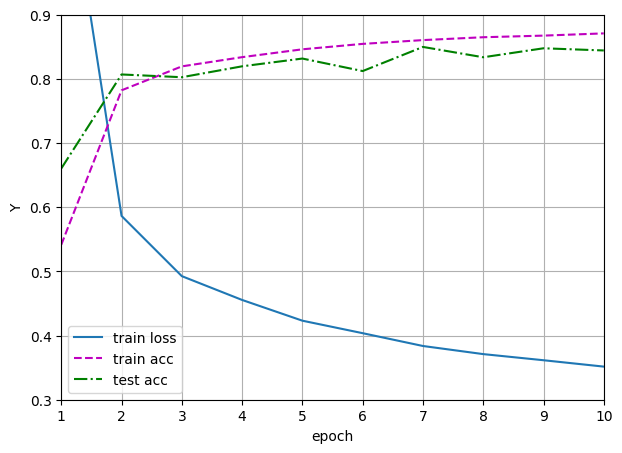

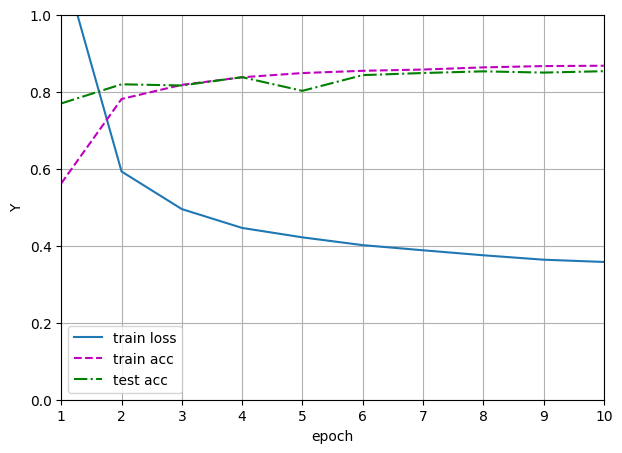

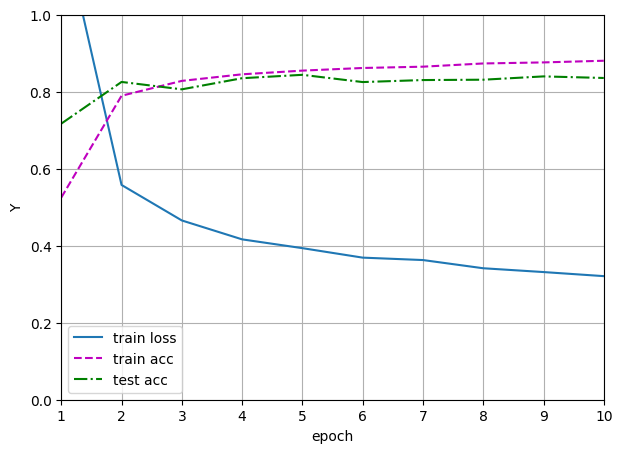

In [11]:
# 只用暂退法
train_loss1, train_acc1, test_acc1 = 0., 0., 0.
for i in range(10):
    show = False if i < 9 else True
    train_losslist1, train_acclist1, test_acclist1 = changedropout(
        dropout1list=[0.2], dropout2list=[0.5], figsize=(7, 5), show=show)
    train_loss1 += train_losslist1[-1][-1][-1] / 10.0
    train_acc1 += train_acclist1[-1][-1][-1] / 10.0
    test_acc1 += test_acclist1[-1][-1][-1] / 10.0
print("only dropout train loss {:.4f} train acc {:.4f} test acc {:.4f}".format(
    train_loss1, train_acc1, test_acc1))

# 暂退法加权重衰减
train_loss2, train_acc2, test_acc2 = 0., 0., 0.
for i in range(10):
    show = False if i < 9 else True
    train_losslist2, train_acclist2, test_acclist2 = changedropout(
        dropout1list=[0.2], dropout2list=[0.5], wd=1e-4, ylim=[0, 1], figsize=(7, 5), show=show)
    train_loss2 += train_losslist2[-1][-1][-1] / 10.0
    train_acc2 += train_acclist2[-1][-1][-1] / 10.0
    test_acc2 += test_acclist2[-1][-1][-1] / 10.0
print("dropout and weight decay train loss {:.4f} train acc {:.4f} test acc {:.4f}".format(
    train_loss2, train_acc2, test_acc2))

# 仅有权重衰减
train_losslist3, train_acclist3, test_acclist3 = changedropout(
    dropout1list=[0], dropout2list=[0], wd=1e-4, ylim=[0, 1], figsize=(7, 5))
print("weight decay train loss {:.4f} train acc {:.4f} test acc {:.4f}".format(
    train_losslist3[-1][-1][-1], train_acclist3[-1][-1][-1], test_acclist3[-1][-1][-1]))


使用 `PyPTO` 编程进行验证:


dropout1=0.2,dropout2=0.5: train_loss=0.3456 train_acc=0.8747 test_acc=0.8385



only dropout train loss 0.3439 train acc 0.8733 test acc 0.8525



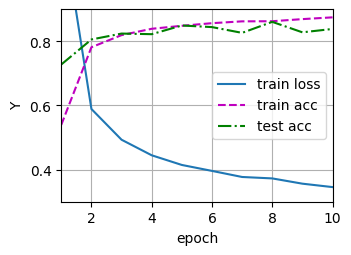

In [12]:
# 练习：只用暂退法（NPU + pypto），重复次数从 10 缩小为 3
train_loss1, train_acc1, test_acc1 = 0., 0., 0.
for i in range(3):
    train_losslist1, train_acclist1, test_acclist1 = changedropout_npu(
        dropout1list=[0.2], dropout2list=[0.5], show=(i == 2))
    train_loss1 += train_losslist1[-1][-1][-1] / 3.0
    train_acc1 += train_acclist1[-1][-1][-1] / 3.0
    test_acc1 += test_acclist1[-1][-1][-1] / 3.0
print("only dropout train loss {:.4f} train acc {:.4f} test acc {:.4f}".format(
    train_loss1, train_acc1, test_acc1))


dropout1=0.2,dropout2=0.5 wd=0.0001: loss=0.3445 train_acc=0.8735 test_acc=0.8528



dropout and weight decay train loss 0.3459 train acc 0.8725 test acc 0.8473



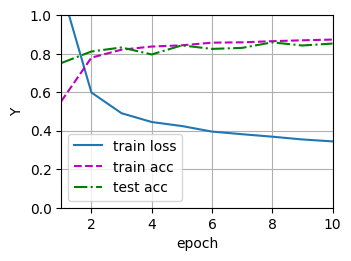

In [13]:
# 练习：暂退法加权重衰减（NPU + pypto），重复次数从 10 缩小为 3
# 权重衰减通过 torch.optim.SGD 的 weight_decay 参数实现
train_loss2, train_acc2, test_acc2 = 0., 0., 0.
def changedropout_npu_wd(dropout1list, dropout2list, num_epochs=10, wd=1e-4, show=True):
    nd1, nd2 = len(dropout1list), len(dropout2list)
    train_iter, test_iter = load_data_fashion_mnist(256)
    for i in range(nd1):
        for j in range(nd2):
            net = Net_npu(dropout1list[i], dropout2list[j])
            updater = torch.optim.SGD(net.parameters(), lr=0.5, weight_decay=wd)
            if show:
                animator = Animator(xlabel='epoch', ylabel='Y',
                                    xlim=[1, num_epochs], ylim=[0, 1],
                                    legend=['train loss','train acc','test acc'])
            for epoch in range(num_epochs):
                tr = train_epoch_npu(net, train_iter, updater)
                te = evaluate_accuracy_npu(net, test_iter)
                if show: animator.add(epoch + 1, tr+(te,))
            train_loss, train_acc = tr
            test_acc = te
            print(f'dropout1={dropout1list[i]},dropout2={dropout2list[j]} wd={wd}: loss={train_loss:.4f} train_acc={train_acc:.4f} test_acc={test_acc:.4f}', flush=True)
    return train_loss, train_acc, test_acc

for i in range(3):
    tr_loss, tr_acc, te_acc = changedropout_npu_wd(
        dropout1list=[0.2], dropout2list=[0.5], num_epochs=10, wd=1e-4, show=(i==2))
    train_loss2 += tr_loss / 3.0
    train_acc2 += tr_acc / 3.0
    test_acc2 += te_acc / 3.0
print("dropout and weight decay train loss {:.4f} train acc {:.4f} test acc {:.4f}".format(
    train_loss2, train_acc2, test_acc2))


dropout1=0,dropout2=0 wd=0.0001: loss=0.3115 train_acc=0.8828 test_acc=0.8636



(0.3114876953125, 0.8828, 0.8636)

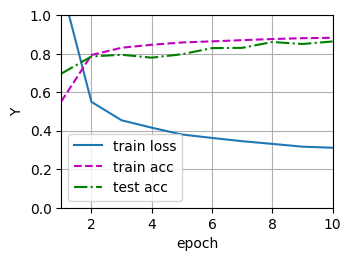

In [14]:
# 练习：只有权重衰减（没有暂退法）（NPU + pypto）
changedropout_npu_wd(dropout1list=[0], dropout2list=[0], num_epochs=10, wd=1e-4)


## 练习4.6.6

如果我们将暂退法应用到权重矩阵的各个权重，而不是激活值，会发生什么？

**解答：** 

将暂退法放在激活函数之前（即对权重矩阵的输出应用dropout），与标准做法（放在激活函数之后）相比，前向传播和反向传播的行为有所不同。

**标准暂退法（在激活值上）：**

设第$l$层的计算为：

$$\mathbf{z}^{(l)} = \mathbf{W}^{(l)} \mathbf{h}^{(l-1)} + \mathbf{b}^{(l)}$$

$$\mathbf{a}^{(l)} = f(\mathbf{z}^{(l)})$$

$$\mathbf{h}^{(l)} = \operatorname{dropout}(\mathbf{a}^{(l)}, p)$$

其中$\operatorname{dropout}(x, p)$表示以概率$p$将元素置零，并以$\frac{1}{1-p}$缩放保留的元素。

反向传播时：

$$\frac{\partial L}{\partial \mathbf{a}^{(l)}} = \frac{\partial L}{\partial \mathbf{h}^{(l)}} \odot \mathbf{m} \cdot \frac{1}{1-p}$$

$$\frac{\partial L}{\partial \mathbf{z}^{(l)}} = \frac{\partial L}{\partial \mathbf{a}^{(l)}} \odot f'(\mathbf{z}^{(l)})$$

$$\frac{\partial L}{\partial \mathbf{W}^{(l)}} = \frac{\partial L}{\partial \mathbf{z}^{(l)}} \cdot (\mathbf{h}^{(l-1)})^\top$$

**将暂退法应用到权重（激活函数之前）：**

此时网络结构变为：

$$\mathbf{z}^{(l)} = \mathbf{W}^{(l)} \mathbf{h}^{(l-1)} + \mathbf{b}^{(l)}$$

$$\mathbf{z}'^{(l)} = \operatorname{dropout}(\mathbf{z}^{(l)}, p)$$

$$\mathbf{h}^{(l)} = f(\mathbf{z}'^{(l)})$$

反向传播时：

$$\frac{\partial L}{\partial \mathbf{z}'^{(l)}} = \frac{\partial L}{\partial \mathbf{h}^{(l)}} \odot f'(\mathbf{z}'^{(l)})$$

$$\frac{\partial L}{\partial \mathbf{z}^{(l)}} = \frac{\partial L}{\partial \mathbf{z}'^{(l)}} \odot \mathbf{m} \cdot \frac{1}{1-p}$$

$$\frac{\partial L}{\partial \mathbf{W}^{(l)}} = \frac{\partial L}{\partial \mathbf{z}^{(l)}} \cdot (\mathbf{h}^{(l-1)})^\top$$

关键区别在于：
1. **梯度流经激活函数的方式不同**：标准做法中，被dropout置零后的激活值不参与反向传播，梯度通过$f'(\mathbf{z}^{(l)})$流向权重；权重dropout中，梯度在通过激活函数$f'$之后才被mask，这意味着即使某个神经元被dropout，其对应的权重梯度仍受到激活函数导数的影响。

2. **dropout的位置影响非线性变换**：权重dropout使得激活函数$f$的输入被随机置零，而标准dropout是使得激活函数的输出被随机置零。前者的随机性在非线性变换之前注入，后者的随机性在非线性变换之后注入。
3. **实验结果表明**：将dropout放在激活函数之前（权重dropout）通常效果不如标准做法，因为激活函数（如ReLU）的非线性特性会在dropout之后进一步扭曲信号分布。

以下使用 `torch` 编程进行验证：


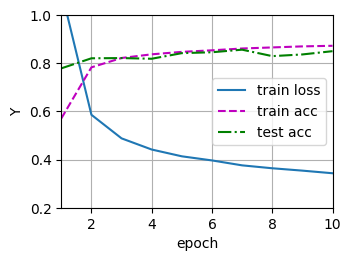

In [15]:
dropout1 = 0.2
dropout2 = 0.5
num_inputs = 784
num_outputs = 10
num_hiddens1 = 256
num_hiddens2 = 256
num_epochs = 10
batch_size = 256
lr = 0.5

net = nn.Sequential(nn.Flatten(),
                    nn.Linear(num_inputs, num_hiddens1),
                    nn.Dropout(dropout1),
                    nn.ReLU(),
                    nn.Linear(num_hiddens1, num_hiddens2),
                    nn.Dropout(dropout2),
                    nn.ReLU(),
                    nn.Linear(num_hiddens2, num_outputs))

train_iter, test_iter = load_data_fashion_mnist(batch_size)
animator = Animator(xlabel='epoch', ylabel='Y', xlim=[1, num_epochs], ylim=[0.2, 1.0],
                    legend=['train loss', 'train acc', 'test acc'])

net.apply(init_weights)
net = net.to(device)
loss = nn.CrossEntropyLoss(reduction='none')
trainer = torch.optim.SGD(net.parameters(), lr=lr)

for epoch in range(num_epochs):
    train_metrics = train_epoch_ch3(net, npu_iter(train_iter), loss, trainer)
    test_acc = evaluate_accuracy(net, npu_iter(test_iter))
    animator.add(epoch + 1, train_metrics + (test_acc,))


使用 `PyPTO` 编程进行验证:


dropout before ReLU: train_loss=0.3400 train_acc=0.8746 test_acc=0.8503



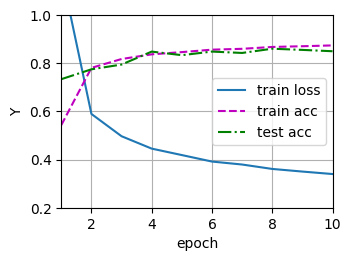

In [16]:
# 练习：dropout 放在 ReLU 之前的效果（NPU + pypto）
net = nn.Sequential(
    nn.Flatten(),
    PyPTOLinear(784, 256),
    PyPTODropout(0.2),
    PyPTOReLU(),
    PyPTOLinear(256, 256),
    PyPTODropout(0.5),
    PyPTOReLU(),
    PyPTOLinear(256, 10),
).to(device)
train_iter, test_iter = load_data_fashion_mnist(256, resize=None)
updater = torch.optim.SGD(net.parameters(), lr=0.5)
animator = Animator(xlabel='epoch', ylabel='Y', xlim=[1, 10], ylim=[0.2, 1.0],
                    legend=['train loss', 'train acc', 'test acc'])
for epoch in range(10):
    tr = train_epoch_npu(net, train_iter, updater)
    te = evaluate_accuracy_npu(net, test_iter)
    animator.add(epoch + 1, tr + (te,))
print(f'dropout before ReLU: train_loss={tr[0]:.4f} train_acc={tr[1]:.4f} test_acc={te:.4f}', flush=True)


## 练习4.6.7

开发另一种用于在每一层注入随机噪声的技术，该技术不同于标准的暂退法技术。

**解答：** 对每一个ReLU输出加上一个高斯噪声。

以下使用 `torch` 编程进行验证：


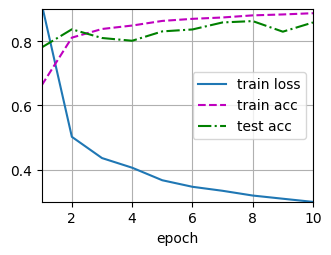

In [17]:
def noise_layer(X, rate=0.1):
    return X + rate * torch.rand(X.shape, device=X.device)

class Net4_6_8(nn.Module):
    def __init__(self, num_inputs, num_outputs, num_hiddens1, num_hiddens2,
                 is_training=True):
        super(Net4_6_8, self).__init__()
        self.num_inputs = num_inputs
        self.training = is_training
        self.lin1 = nn.Linear(num_inputs, num_hiddens1)
        self.lin2 = nn.Linear(num_hiddens1, num_hiddens2)
        self.lin3 = nn.Linear(num_hiddens2, num_outputs)
        self.relu = nn.ReLU()

    def forward(self, X):
        H1 = self.relu(self.lin1(X.reshape((-1, self.num_inputs))))
        if self.training == True:
            H1 = noise_layer(H1)
        H2 = self.relu(self.lin2(H1))
        if self.training == True:
            H2 = noise_layer(H2)
        out = self.lin3(H2)
        return out

num_inputs, num_outputs, num_hiddens1, num_hiddens2 = 784, 10, 256, 256

net = Net4_6_8(num_inputs, num_outputs, num_hiddens1, num_hiddens2)
net = net.to(device)
num_epochs, lr, batch_size = 10, 0.5, 256
loss = nn.CrossEntropyLoss(reduction='none')
train_iter, test_iter = load_data_fashion_mnist(batch_size)
trainer = torch.optim.SGD(net.parameters(), lr=lr)
train_ch3(net, npu_iter(train_iter), npu_iter(test_iter), loss, num_epochs, trainer)


使用 `PyPTO` 编程进行验证:


In [18]:
from src.utils import load_data_fashion_mnist
def noise_layer(X, rate=0.1):
    return X + rate * torch.rand(X.shape, device=X.device)

class Net4_6_8(nn.Module):
    def __init__(self, num_inputs, num_outputs, num_hiddens1, num_hiddens2,
                 is_training=True):
        super(Net4_6_8, self).__init__()
        self.num_inputs = num_inputs
        self.training = is_training
        self.lin1 = PyPTOLinear(num_inputs, num_hiddens1)
        self.lin2 = PyPTOLinear(num_hiddens1, num_hiddens2)
        self.lin3 = PyPTOLinear(num_hiddens2, num_outputs)
        self.relu = PyPTOReLU()

    def forward(self, X):
        H1 = self.relu(self.lin1(X.reshape((-1, self.num_inputs))))
        if self.training == True:
            H1 = noise_layer(H1)
        H2 = self.relu(self.lin2(H1))
        if self.training == True:
            H2 = noise_layer(H2)
        out = self.lin3(H2)
        return out

num_inputs, num_outputs = 784, 10
num_hiddens1, num_hiddens2 = 256, 256
net = Net4_6_8(num_inputs, num_outputs, num_hiddens1, num_hiddens2).to(device)
num_epochs, lr, batch_size = 10, 0.5, 256
loss = lambda y_hat, y: PyPTOSoftmaxCrossEntropyLossFunction.apply(y_hat, y, num_outputs)
train_iter, test_iter = load_data_fashion_mnist(batch_size)
trainer = torch.optim.SGD(net.parameters(), lr=lr)

for epoch in range(num_epochs):
    net.train()
    for X, y in train_iter:
        X, y = X.to(device), y.to(device)
        trainer.zero_grad()
        l = loss(net(X), y)
        l.mean().backward()
        trainer.step()
    net.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X, y in test_iter:
            X, y = X.to(device), y.to(device)
            pred = net(X).argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.numel()
    print(f"epoch {epoch + 1}, test_acc {correct / total:.4f}")


epoch 1, test_acc 0.6848



epoch 2, test_acc 0.7974



epoch 3, test_acc 0.7998



epoch 4, test_acc 0.7993



epoch 5, test_acc 0.8243



epoch 6, test_acc 0.8144



epoch 7, test_acc 0.7892



epoch 8, test_acc 0.8330



epoch 9, test_acc 0.8487



epoch 10, test_acc 0.8612



---
## 参考答案来源
参考答案和 PyTorch 代码实现来源：[https://datawhalechina.github.io/d2l-ai-solutions-manual/#/](https://datawhalechina.github.io/d2l-ai-solutions-manual/#/)
